In [3]:
import os

import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = os.path.join("..", "data")

## GDP per capita

In [4]:
from scripts.preprocess_data import process_WB_dataframe

# GDP per capita
# main file + 2 metadata files (not too important for us)
gdp_per_capita_df = pd.read_csv(f'{DATA_DIR}/gdp_per_capita/gdp_per_capita_data.csv', skiprows=4)
gdp_per_capita_df = process_WB_dataframe(gdp_per_capita_df)

# Health per capita
# main file + 2 metadata files (not too important for us)
health_per_capita_df = pd.read_csv(f'{DATA_DIR}/health_per_capita/health_per_capita_data.csv', skiprows=4)
health_per_capita_df = process_WB_dataframe(health_per_capita_df)

## Process WHO data

In [5]:
from scripts.preprocess_data import drop_columns

# NCD_PAC - Prevalence of insufficient physical activity among adults aged 18+ years (crude estimate) (%)
NCD_PAC_df = pd.read_csv(f'{DATA_DIR}/physical_activity/NCD_PAC.csv')
NCD_PAC_df = drop_columns(NCD_PAC_df)

# NCD_PAA	Prevalence of insufficient physical activity among adults aged 18+ years (age-standardized estimate) (%)
NCD_PAA_df = pd.read_csv(f'{DATA_DIR}/physical_activity/NCD_PAA.csv')
NCD_PAA_df = drop_columns(NCD_PAA_df)

# SA_0000001400	- Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol), by beverage type	
SA_0000001400_df = pd.read_csv(f'{DATA_DIR}/alcohol_consumption/alcohol.csv')
SA_0000001400_df = drop_columns(SA_0000001400_df)

# NCD_UNDER70 - Premature deaths due to noncommunicable diseases (NCD) as a proportion of all NCD deaths
NCD_UNDER70_df = pd.read_csv(f'{DATA_DIR}/mortality/NCD_UNDER70.csv')
NCD_UNDER70_df = drop_columns(NCD_UNDER70_df)

# WHS2_131 - Total NCD mortality rate  (per 100 000 population) , age-standardized
WHS2_131_df = pd.read_csv(f'{DATA_DIR}/mortality/WHS2_131.csv')
WHS2_131_df = drop_columns(WHS2_131_df)

Now all of our data is in the same structure!

## Further preprocessing the data

1. merge all indicators in one dataframe
2. clean data from NaN values
3. group by indicators and countries
4. plots for visualization

In [6]:
## 1. merge data

dataframes = [
    gdp_per_capita_df,
    health_per_capita_df,
    NCD_PAC_df,
    NCD_PAA_df,
    SA_0000001400_df,
    NCD_UNDER70_df,
    WHS2_131_df
]

df = pd.concat(
    dataframes,
    ignore_index=True
)

# rename some of the columns for readability
df.rename(
    {
        'IndicatorCode': 'Indicator',
        'SpatialDim': 'Country',
        'TimeDim': 'Year',
        'NumericValue': 'Value'
    },
    axis=1,
    inplace=True
)

print('# of rows:   ', df.shape[0])
print('# of columns:', df.shape[1])

# of rows:    139318
# of columns: 4


In [7]:
## 2. clean data
# - drop duplicates
# - drop Na values

original_row_num = df.shape[0]

df = df.drop_duplicates()
duplicates_dropped = original_row_num - df.shape[0]

df = df.dropna()
na_values_dropped = original_row_num - duplicates_dropped - df.shape[0]

print('Original # of rows:     ', original_row_num)
print('Duplicate rows dropped: ', duplicates_dropped)
print('Na values dropped:      ', na_values_dropped)
print('New # of rows:          ', df.shape[0])

Original # of rows:      139318
Duplicate rows dropped:  3119
Na values dropped:       14574
New # of rows:           121625


In [8]:
## 3. group by indicators and countries

grouped = df.groupby(['Indicator', 'Country'])
available_groups = grouped.groups.keys()
list_of_groups = list(available_groups)

# list of all unique indicators
unique_indicators = df['Indicator'].unique()

print("Unique Indicators:")
print(unique_indicators)

# list of all unique countries
unique_countries = df['Country'].unique()

print("\nUnique Countries:")
print(unique_countries)


Unique Indicators:
['NY.GDP.PCAP.CD' 'SH.XPD.CHEX.PC.CD' 'NCD_PAC' 'NCD_PAA' 'SA_0000001400'
 'NCD_UNDER70' 'WHS2_131']

Unique Countries:
['AFE' 'AFW' 'ARG' 'AUS' 'AUT' 'BDI' 'BEL' 'BEN' 'BFA' 'BGD' 'BHS' 'BLZ'
 'BMU' 'BOL' 'BRA' 'BRB' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR'
 'COD' 'COG' 'COL' 'CRI' 'CSS' 'DEU' 'DNK' 'DOM' 'DZA' 'EAP' 'EAR' 'EAS'
 'ECS' 'ECU' 'EGY' 'EMU' 'ESP' 'ETH' 'EUU' 'FCS' 'FIN' 'FJI' 'FRA' 'GAB'
 'GBR' 'GHA' 'GRC' 'GTM' 'GUY' 'HIC' 'HKG' 'HND' 'HPC' 'HTI' 'IBD' 'IBT'
 'IDA' 'IDB' 'IDX' 'IND' 'IRL' 'IRN' 'IRQ' 'ISL' 'ISR' 'ITA' 'JAM' 'JPN'
 'KEN' 'KNA' 'KOR' 'LAC' 'LBR' 'LBY' 'LCN' 'LDC' 'LKA' 'LMC' 'LMY' 'LSO'
 'LTE' 'LUX' 'MAR' 'MDG' 'MEA' 'MEX' 'MIC' 'MMR' 'MNA' 'MUS' 'MYS' 'NAC'
 'NER' 'NGA' 'NIC' 'NLD' 'NOR' 'NPL' 'NZL' 'OED' 'OMN' 'PAK' 'PAN' 'PER'
 'PHL' 'PNG' 'PRE' 'PRI' 'PRT' 'PRY' 'PST' 'RWA' 'SAS' 'SAU' 'SDN' 'SEN'
 'SGP' 'SLE' 'SOM' 'SSA' 'SSF' 'SUR' 'SWE' 'SWZ' 'SYC' 'SYR' 'TCD' 'TEA'
 'TGO' 'THA' 'TLA' 'TMN' 'TSA' 'TSS' 'TTO' 'TUR' 'TZA' 'UG

           Indicator Country  Year        Value
251   NY.GDP.PCAP.CD     USA  1960  3002.089295
517   NY.GDP.PCAP.CD     USA  1961  3062.974116
783   NY.GDP.PCAP.CD     USA  1962  3241.857659
1049  NY.GDP.PCAP.CD     USA  1963  3373.357305
1315  NY.GDP.PCAP.CD     USA  1964  3573.063546


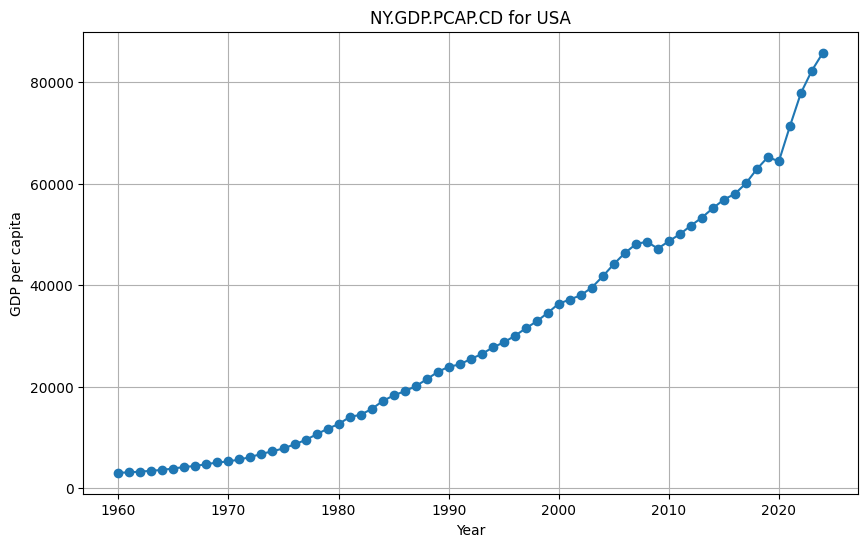

In [9]:
## 4. visualization

indicator_code = 'NY.GDP.PCAP.CD'
spatial_dim = 'USA'

# Get the specific DataFrame for plotting
group_df = grouped.get_group((indicator_code, spatial_dim))

print(group_df.head())

def plot_simple_scatter(df: pd.DataFrame, xlabel: str = None):
    plt.figure(figsize=(10, 6))
    plt.plot(df['Year'], df['Value'], marker='o')
    plt.title(f'{indicator_code} for {spatial_dim}')
    plt.xlabel('Year')      
    plt.ylabel('Value' if xlabel is None else xlabel)
    plt.grid(True)
    plt.show()

plot_simple_scatter(group_df, "GDP per capita")

## Outlier detection

In [10]:
from scipy.stats import zscore


def zscore_stats(group):
    # calculate z-score for current group
    zscores = zscore(group['Value'])

    # return aggregated statistics
    return pd.Series({
        'zscore_min': zscores.min(),
        'zscore_max': zscores.max(),
        'zscore_mean': zscores.mean()
    })

# get aggregated zscore statistics for all groups
zscore_summary_df = (
    df
    .groupby(['Indicator', 'Country'])
    .apply(zscore_stats)
    .reset_index()
)

# 3. Print the resulting DataFrame
print("\nZ-Score Summary for Outlier Detection:")
print(zscore_summary_df.head())


Z-Score Summary for Outlier Detection:
  Indicator Country  zscore_min  zscore_max   zscore_mean
0   NCD_PAA     AFG   -1.359396    2.162141  1.737740e-16
1   NCD_PAA     AFR   -1.738863    2.065511  1.166539e-16
2   NCD_PAA     AGO   -1.718933    1.987077  4.505253e-16
3   NCD_PAA     ALB   -1.807266    1.730792 -1.275550e-15
4   NCD_PAA     AMR   -1.681638    2.197376 -1.774748e-15


/tmp/ipykernel_53254/1178111737.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(zscore_stats)


Generating 7 scatter plots...


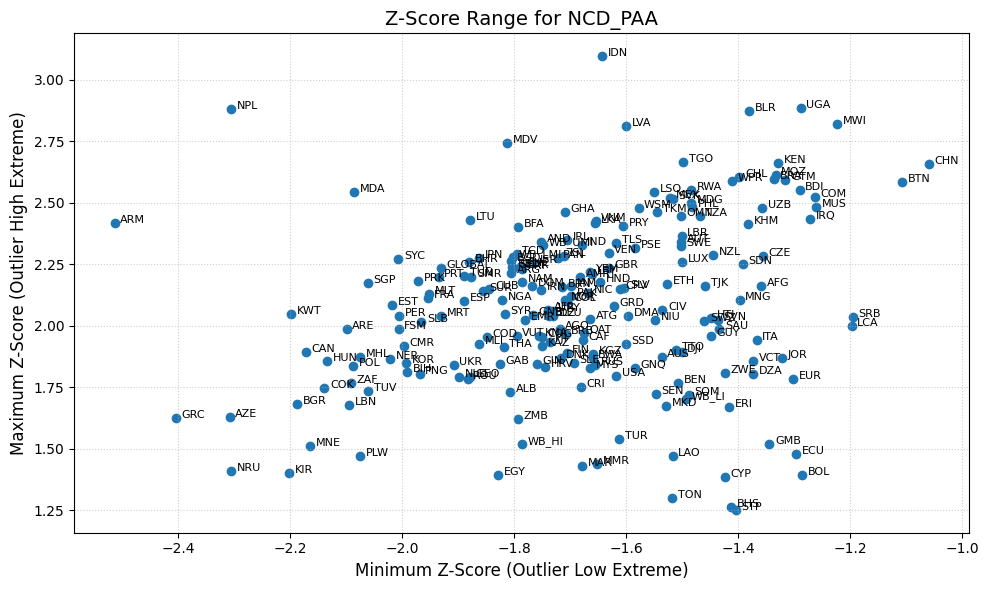

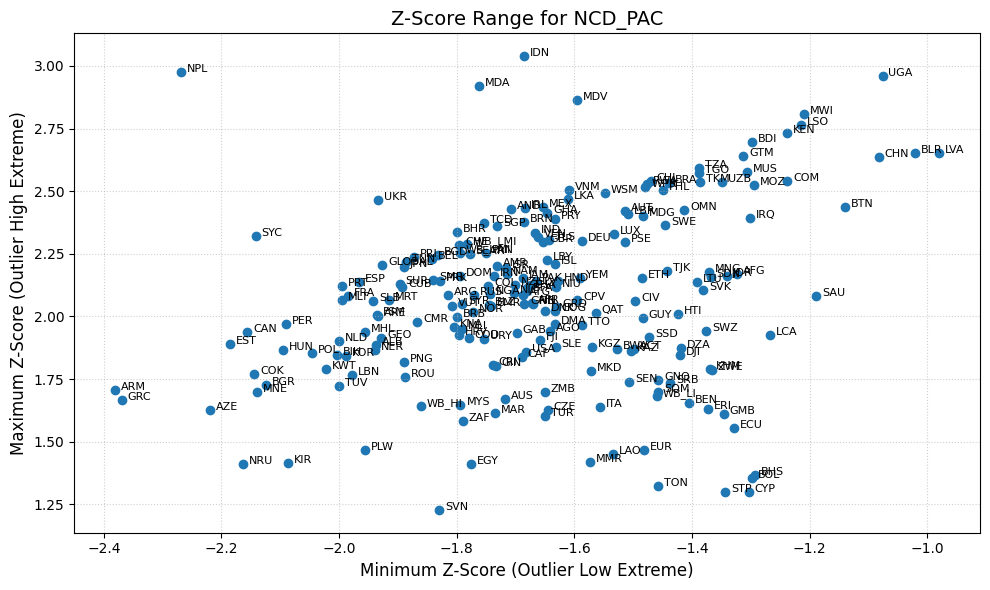

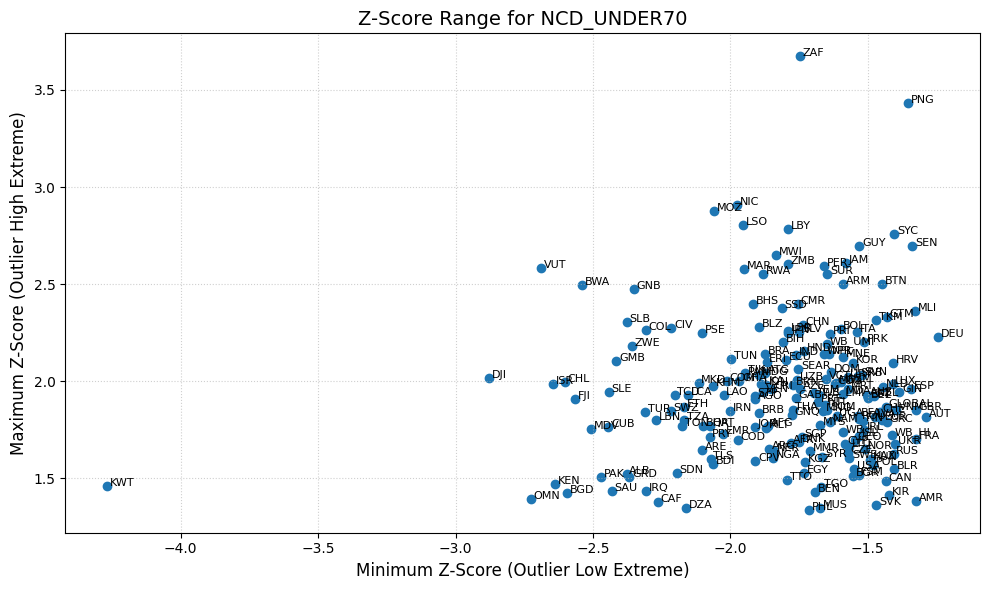

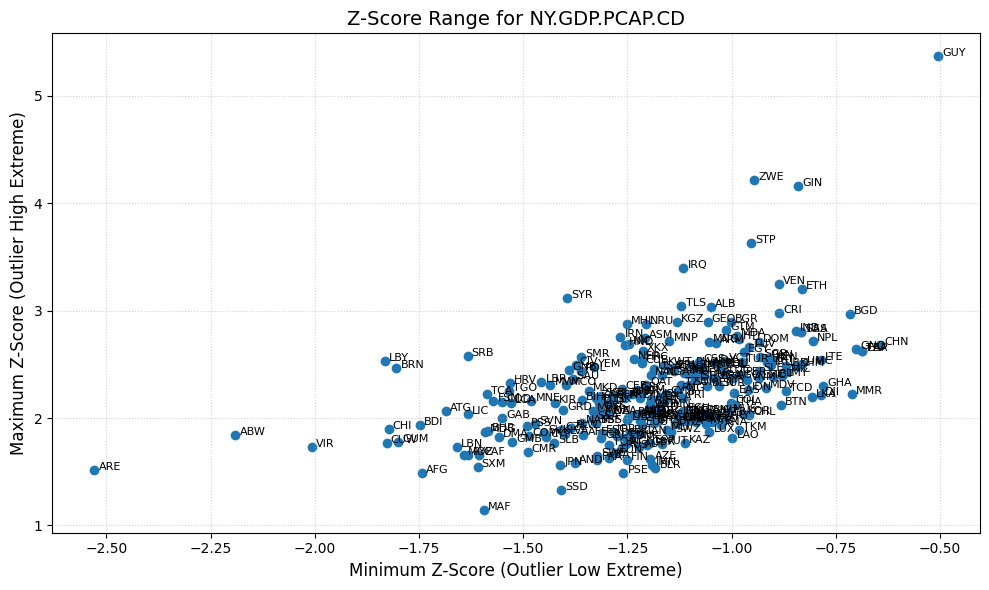

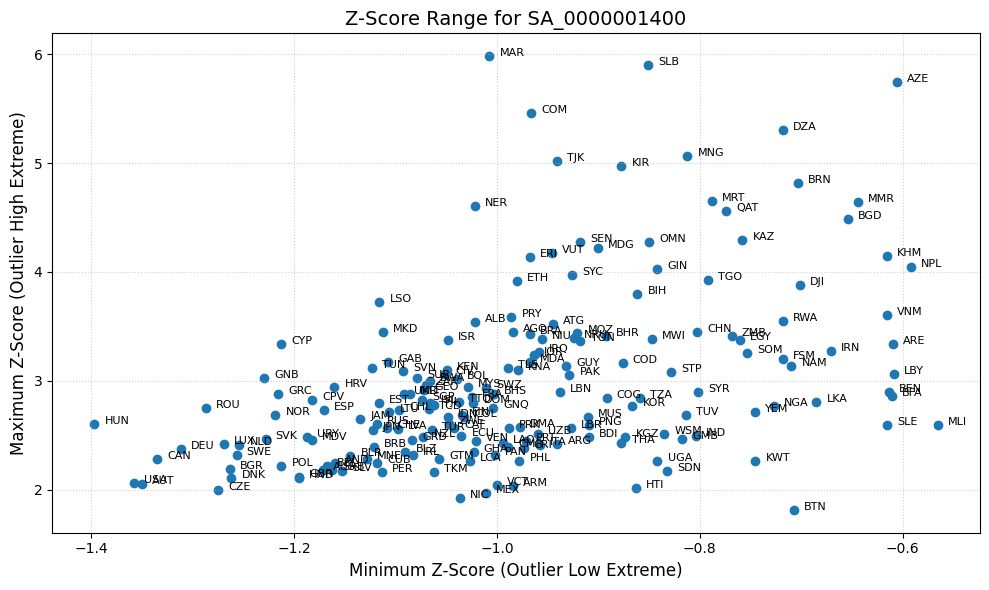

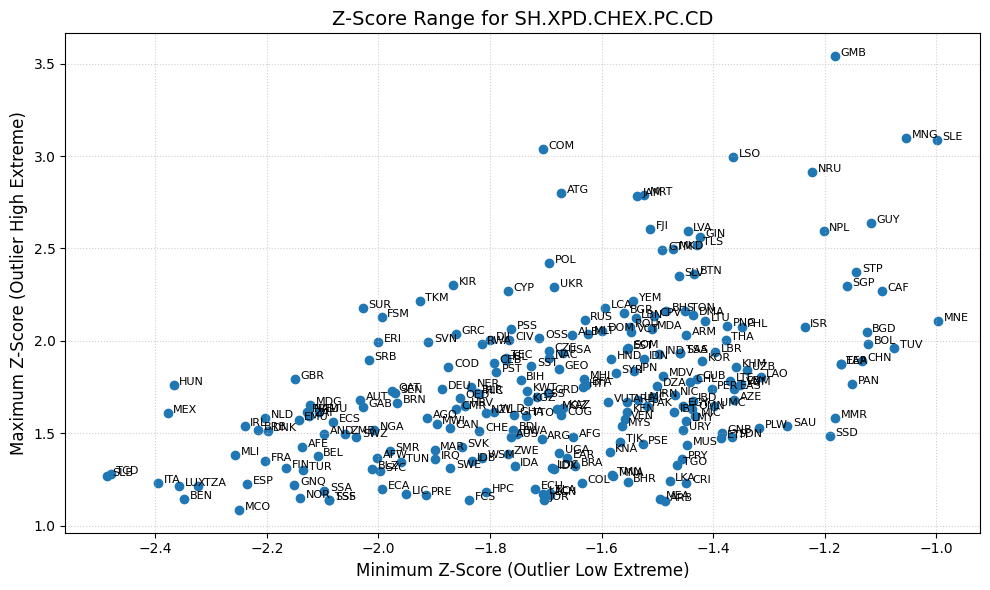

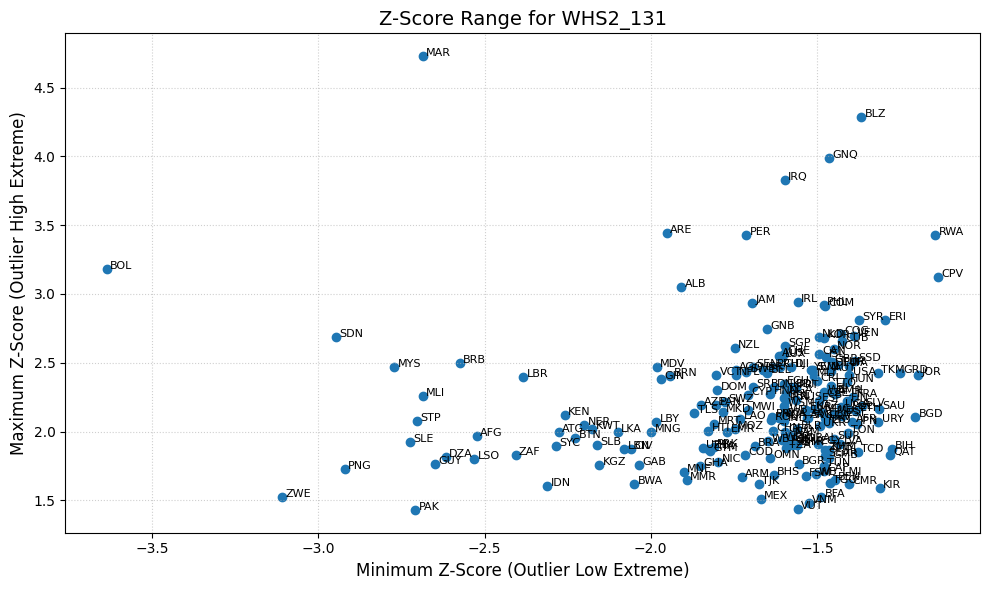

In [11]:
unique_indicators = zscore_summary_df['Indicator'].unique()
print(f"Generating {len(unique_indicators)} scatter plots...")

for indicator in unique_indicators:
    # get data for current indicator
    plot_df = zscore_summary_df[zscore_summary_df['Indicator'] == indicator]
    
    plt.figure(figsize=(10, 6))
    plt.scatter(plot_df['zscore_min'], plot_df['zscore_max'])
    
    # annotation
    for i, row in plot_df.iterrows():
        plt.annotate(row['Country'], (row['zscore_min']+0.01, row['zscore_max']), fontsize=8)
    
    plt.title(f'Z-Score Range for {indicator}', fontsize=14)
    plt.xlabel('Minimum Z-Score (Outlier Low Extreme)', fontsize=12)
    plt.ylabel('Maximum Z-Score (Outlier High Extreme)', fontsize=12)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()

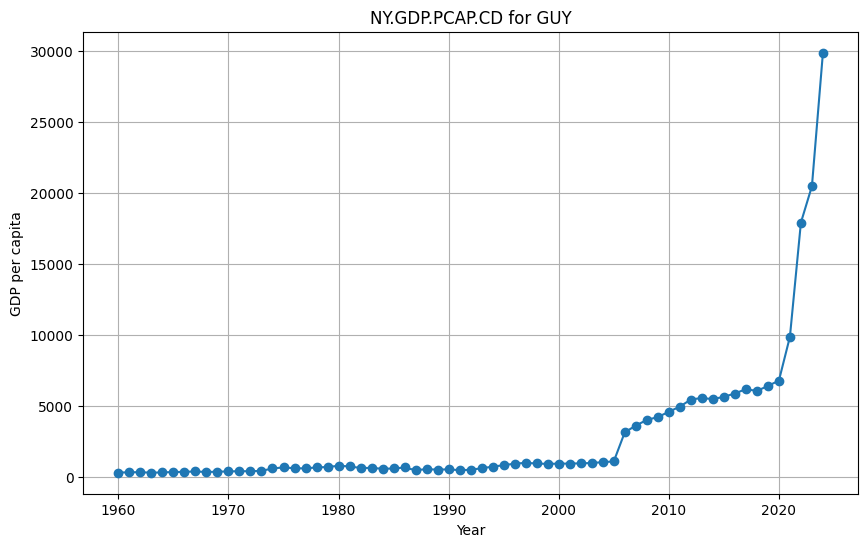

In [12]:
## Example 1 - GDP per capita / Guyana
indicator_code = 'NY.GDP.PCAP.CD'
spatial_dim = 'GUY'
group_df = grouped.get_group((indicator_code, spatial_dim))

plot_simple_scatter(group_df, 'GDP per capita')

# Guyana has underwent a major GDP growth driven by its oil production.

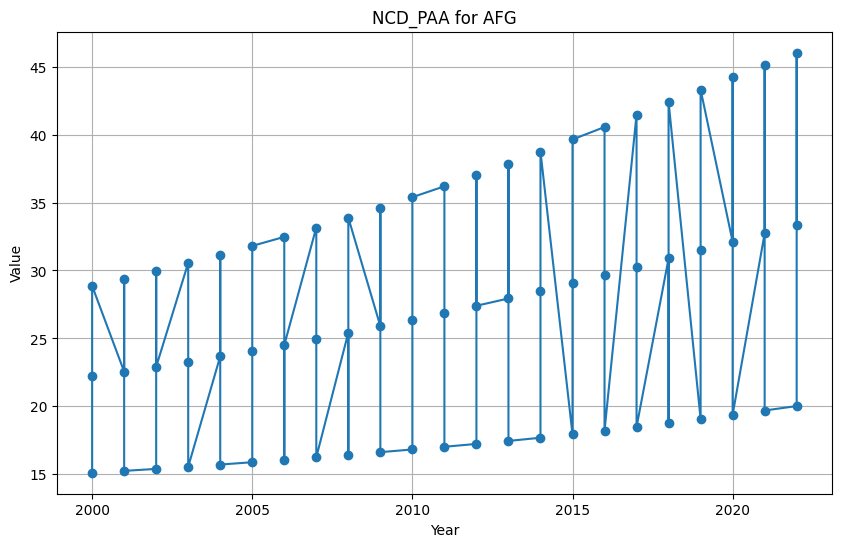

In [13]:
## Example 2 - Multiple data points

indicator_code = 'NCD_PAA'
spatial_dim = 'AFG'
group_df = grouped.get_group((indicator_code, spatial_dim)).sort_values(by='Year', axis=0, ascending=True)

plot_simple_scatter(group_df)

In [14]:
# It seems there are mutliple datapoints in a year for a group of (Indicator, Country)
print("Indicators and the minimum number of datapoints for a country and year pair.")
number_of_datapoints = df.groupby(['Indicator', 'Country', 'Year']).count()\
    .groupby(['Indicator', 'Country']).min()\
    .groupby('Indicator').min()
print(number_of_datapoints.to_string())
print("A higher than 1 value could suggest that the indicator is an estimate!")

Indicators and the minimum number of datapoints for a country and year pair.
                   Value
Indicator               
NCD_PAA                3
NCD_PAC                3
NCD_UNDER70            3
NY.GDP.PCAP.CD         1
SA_0000001400          1
SH.XPD.CHEX.PC.CD      1
WHS2_131               3
A higher than 1 value could suggest that the indicator is an estimate!


         Indicator Country  Year        Value
1   NY.GDP.PCAP.CD     AFE  1960   186.121835
3   NY.GDP.PCAP.CD     AFW  1960   121.939925
9   NY.GDP.PCAP.CD     ARG  1960   778.251707
13  NY.GDP.PCAP.CD     AUS  1960  1810.706430
14  NY.GDP.PCAP.CD     AUT  1960   939.914815


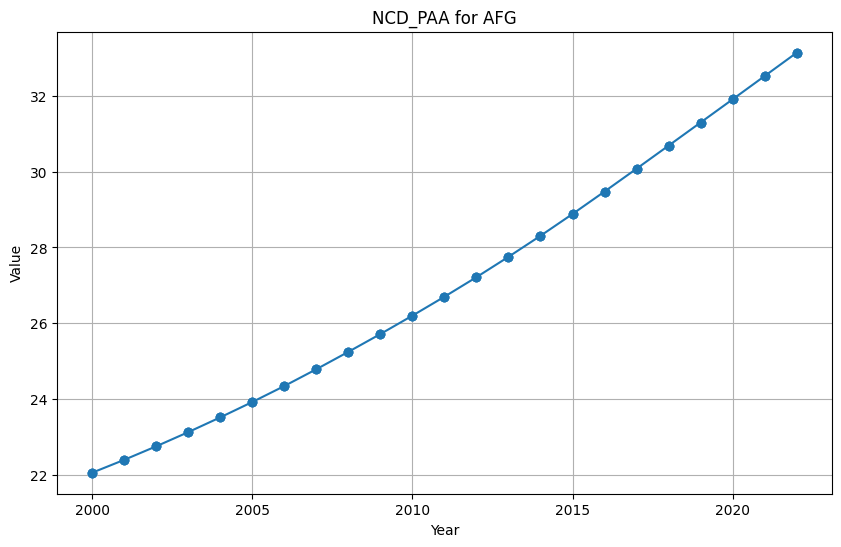

In [15]:
# Take the mean of the datapoints
df['Value'] = df.groupby(['Indicator', 'Country', 'Year'])['Value'].transform('mean')
print(df.head())

indicator_code = 'NCD_PAA'
spatial_dim = 'AFG'
group_df = grouped.get_group((indicator_code, spatial_dim)).sort_values(by='Year', axis=0, ascending=True)
plot_simple_scatter(group_df)

In [16]:
from scripts.preprocess_data import process_data

# this script does everything from the above steps in one go
df = process_data()
df.head()

Loading World Bank data...
  > gdp_per_capita_data - Done
  > health_per_capita_data - Done
Loading WHO data...
  > NCD_PAC - Done
  > NCD_PAA - Done
  > alcohol - Done
  > NCD_UNDER70 - Done
  > WHS2_131 - Done
Dataframes processed: ['gdp_per_capita_data', 'health_per_capita_data', 'NCD_PAC', 'NCD_PAA', 'alcohol', 'NCD_UNDER70', 'WHS2_131']
Merged dataframe:
  # of rows:    139318
  # of columns: 4
Cleaning info:
  Original # of rows:      139318
  Duplicate rows dropped:  3119
  Na values dropped:       14574
  New # of rows:           121625
Unique Indicators:
['NY.GDP.PCAP.CD' 'SH.XPD.CHEX.PC.CD' 'NCD_PAC' 'NCD_PAA' 'SA_0000001400'
 'NCD_UNDER70' 'WHS2_131']

Unique Countries:
['AFE' 'AFW' 'ARG' 'AUS' 'AUT' 'BDI' 'BEL' 'BEN' 'BFA' 'BGD' 'BHS' 'BLZ'
 'BMU' 'BOL' 'BRA' 'BRB' 'BWA' 'CAF' 'CAN' 'CHE' 'CHL' 'CHN' 'CIV' 'CMR'
 'COD' 'COG' 'COL' 'CRI' 'CSS' 'DEU' 'DNK' 'DOM' 'DZA' 'EAP' 'EAR' 'EAS'
 'ECS' 'ECU' 'EGY' 'EMU' 'ESP' 'ETH' 'EUU' 'FCS' 'FIN' 'FJI' 'FRA' 'GAB'
 'GBR' 'GHA' 'GRC'

,Indicator,Country,Year,Value
1,NY.GDP.PCAP.CD,AFE,1960,186.121835
3,NY.GDP.PCAP.CD,AFW,1960,121.939925
9,NY.GDP.PCAP.CD,ARG,1960,778.251707
13,NY.GDP.PCAP.CD,AUS,1960,1810.706430
14,NY.GDP.PCAP.CD,AUT,1960,939.914815
